In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
# Check number of missing values
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

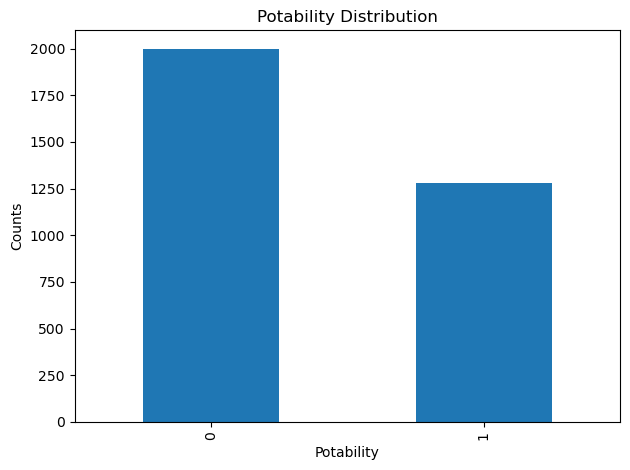

In [5]:
# Visualize distribution of response variable
fig, ax = plt.subplots()
df['Potability'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Potability Distribution')
ax.set_ylabel('Counts')
fig.tight_layout()

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [6]:
# Impute missing values using column medians
df_clean = df.fillna(df.median())


# Set up predictors and response
X = df_clean.drop(columns = 'Potability')
y = df_clean['Potability']

# Split data at 70/30 with stratification

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.7,
                                                    stratify = y ,
                                                   random_state = 42)

In [7]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [8]:
# Fit unpruned tree
dt_unpruned = DecisionTreeClassifier(random_state =42).fit(X_train, y_train)

# Get tree depth
tree_depth = dt_unpruned.get_depth()

# Predict on train and test 
y_train_pred = dt_unpruned.predict(X_train)
y_test_pred = dt_unpruned.predict(X_test)

# Compute accuracy scores
dt_unpruned_acc_train = accuracy_score(y_train, y_train_pred)
dt_unpruned_acc_test  = accuracy_score(y_test, y_test_pred)

print("Tree Depth:", tree_depth)
print("Train Accuracy:", dt_unpruned_acc_train)
print("Test Accuracy:", dt_unpruned_acc_test)

Tree Depth: 33
Train Accuracy: 1.0
Test Accuracy: 0.5808748728382502


In [9]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The unpruned tree has 100% training accuracy, perfect. The test accuracy is only 58%. What this means is that the unpruned tree is overfitting the data, since it performs poorly on unseen (test) data. The tree is basically memorizing the data and will not generalize well to new observations. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Optimal Depth: 7


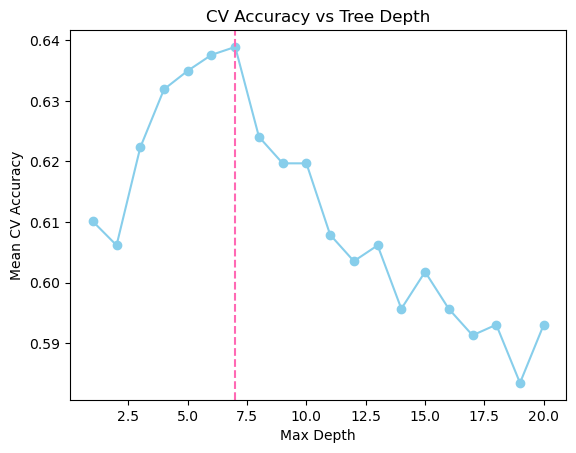

In [10]:
depths = np.arange(1, 21)
cv_accuracies = []

# Test range of depths
for depth in depths:
    dt = DecisionTreeClassifier(
    max_depth = depth,
    random_state = 42)
    scores = cross_val_score(dt, 
                             X_train,
                             y_train, 
                             cv = 5, 
                             scoring = "accuracy")
    cv_accuracies.append(scores.mean())

# Find the optimal depth
optimal_depth   = depths[np.argmax(cv_accuracies)]

print("Optimal Depth:", optimal_depth)

# Plot CV accuracy vs depth
plt.plot(depths, cv_accuracies, color = 'skyblue', marker = 'o')
plt.axvline(optimal_depth, linestyle='--', color = 'hotpink')
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("CV Accuracy vs Tree Depth")
plt.show()


In [11]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

The CV found the optimal depth to be 7. This means that a tree with 7 levels learns patterns in the training data AND generalizes well to unseen (test) data. The depth of 7 achieved the highest average validation accuracy across the folds. 

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [12]:
# Fit tuned decision tree using optimal depth
dt_opt = DecisionTreeClassifier(
    max_depth = optimal_depth,
    random_state = 42).fit(X_train,
                           y_train)

# Compute test set accuracy
acc_dt    = dt_opt.score(X_test, y_test)

print("Tuned Tree Test Accuracy:", acc_dt)


Tuned Tree Test Accuracy: 0.6459816887080366


In [13]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Yes, the accuracy of the tuned decision tree improved (0.65), compared to that of the untuned tree (0.58). By limiting the tree depth to the optimal depth (7), the tuned tree was less complex, less likely to simply memorize the training set patterns, and generalizes better to unseen (test) data. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

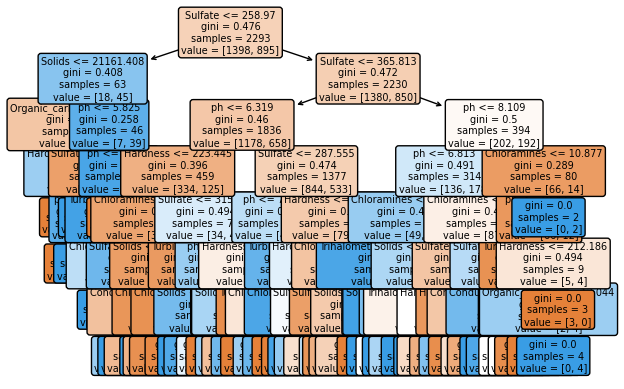

In [14]:
# Plot the tuned tree
plt.figure()
plot_tree(dt_opt, 
          feature_names = df.columns,
          filled=True, 
          rounded=True, 
          fontsize=7)
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The root split uses the feature `Sulfate` with a threshold of 258.97. This means the tree determined that Sulfate was the most significant predictor of potability. The root node is chosen because it produces the greatest reduction in impurity, so this suggests `Sulfate` has a strong relationship with potability.

The Gini impurity at the root node is 0.476, indicating a relatively mixed set of classes at the start. After the first split, the Gini impurity decreases in the  nodes (for example, to 0.408 and 0.472), which means the split created groups that are somewhat more homogeneous in terms of potability classification.

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [15]:
# Fit a random forest model

rf = RandomForestClassifier(
        n_estimators = 200,
        random_state = 42).fit(X_train, 
                               y_train)
# Predict on test set
y_pred_rf = rf.predict(X_test)

# Calculate test accuracy
acc_rf    = accuracy_score(y_test,
                           y_pred_rf)

print("Random Forest Test Accuracy:", acc_rf)


Random Forest Test Accuracy: 0.6612410986775178


In [16]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The Random Forest model performed slightly better than the tuned Decision Tree. The tuned Decision Tree achieved a test accuracy of 0.646, while the Random Forest achieved a higher test accuracy of 0.661.

This improvement is likely because Random Forest reduces the high variance associated with a single decision tree. Random Forest combines predictions from many trees built on bootstrap samples of the data, and each split only considers a random subset of predictors, which reduces correlation among the trees. Since it averages across many correlation-reduced trees, generalization is improved and leads to better performance on unseen (test) data.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

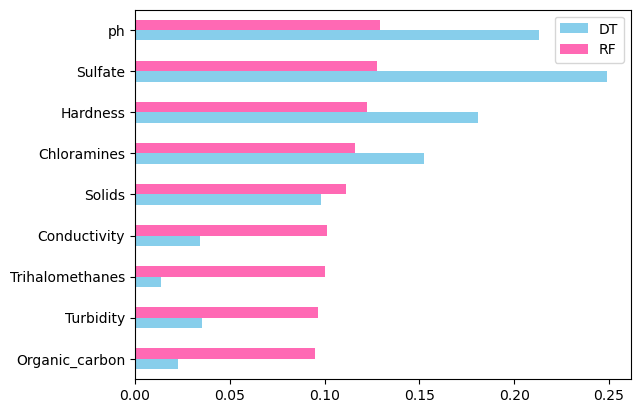

In [17]:
# Create bar plot showing feature importances of tuned tree and random forest
combined_importance = pd.DataFrame({
    'DT': dt_opt.feature_importances_,
    'RF': rf.feature_importances_
}, index= X.columns)

combined_importance.sort_values(by='RF').plot(
    kind='barh',
    color=['skyblue', 'hotpink']
)

plt.show()



> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

The Decision Tree and Random Forest agree on some of the most important features, particularly `Sulfate`, `pH`, `Hardness`, and `Chloramines`, which appear among the top predictors in both models. The exact importance rankings differ between the two models. The Decision Tree places especially high importance on `Sulfate` and `pH`, and Random Forest distributes importance more evenly across features.

A single decision tree’s feature importances may be less reliable because the tree is highly sensitive to the specific training data. One split early in the tree may dominate the importance calculations. Random Forest averages feature importance across many trees built on different bootstrap samples and random subsets of predictors, making the importance estimates more stable and less sensitive to noise or  training observations.

Sulfate appears to be the most important feature overall for predicting potability, with pH following closely. This does make physical sense, since high sulfate concentrations can affect water quality and safety. 

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

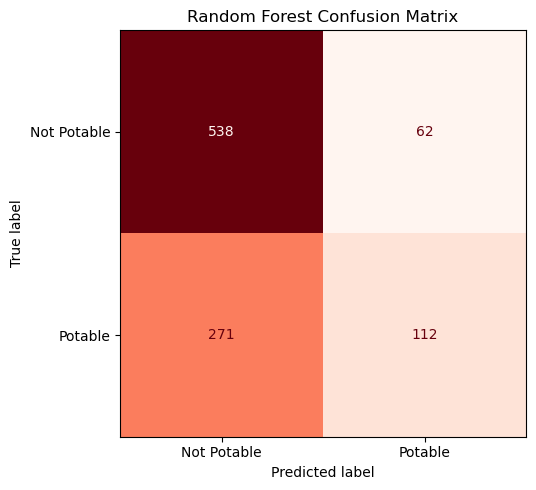

In [18]:
# Create confusion matrix of random forest model
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Potable', 'Potable'])


fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Random Forest Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()
     


<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

- TP: 112 water samples were correctly predicted as potable.

- TN: 538 water samples were correctly predicted as non-potable.

- FP: 62 not-potable samples were incorrectly predicted as potable.

- FN: 271 potable samples were incorrectly predicted as non-potable.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [19]:
#Create table showing all test accuracies
test_acc_table = pd.DataFrame({
    'Model':['DT Untuned', 'DT Tuned', 'Random Forest'],
    'Test Accuracy':[dt_unpruned_acc_test, acc_dt, acc_rf]
})    

test_acc_table

,Model,Test Accuracy
0,DT Untuned,0.580875
1,DT Tuned,0.645982
2,Random Forest,0.661241


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The Random Forest model achieved the highest test accuracy at 0.661. The tuned Decision Tree achieved a test accuracy of 0.646, and the unpruned one 0.581, the difference being about 0.065 or 6.5%. This improvement is significant, the pruning reduced complexity of the model and made it more generalizable to the test set/new observations. 

---

Run the cell below to receive credit for autograded questions. 

In [20]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!